# Fundamentals of Software Systems (FSS)
**Software Evolution – Part 02 Assignment**

## Submission Guidelines

To correctly complete this assignment you must:
* Carry out the assignment in a team of 2 to 4 students.
* Carry out the assignment with your team only. You are allowed to discuss solutions with other teams, but each team should come up its own personal solution. A strict plagiarism policy is going to be applied to all the artifacts submitted for evaluation.
* As your submission, upload the filled Jupyter Notebook (including outputs) together with the d3 visualization web pages (i.e. upload everything you downloaded including the filled Jupyter Notebook plus your `output.json`)
* The files must be uploaded to OLAT as a single ZIP (`.zip`) file by Dec 15, 2025 @ 23:55.


## Group Members
* Patric, Brandao, 21-534-607
* Noah Mattia, Bussinger, 22-700-835

## Task Context

In this assigment we will be analyzing the _elasticsearch_ project. All following tasks should be done with the subset of commits from tag `v0.90.0` to tag `v1.0.0.RC1`.

In [41]:
from enum import Enum
import pydriller
from collections import defaultdict
import matplotlib.pyplot
import pandas
import json
import os

class Modification(Enum):
    ADDED = "Lines added"
    REMOVED = "Lines removed"
    TOTAL = "Lines added + lines removed"
    DIFF = "Lines added - lines removed"

path_to_elasticsearch = "add your path to elasticsearch repo"
repo = pydriller.Repository(path_to_elasticsearch,
                            from_tag="v0.90.0",
                            to_tag="v1.0.0.RC1")


## Task 1: Author analysis

In the following, please consider only `java` files.

The first task is to get an overview of the author ownership of the _elasticsearch_ project. In particular, we want to understand who are the main authors in the system between the two considered tags, the authors distribution among files and the files distribution among authors. To this aim, perform the following:
- create a dictionary (or a list of tuples) with the pairs author => number of modified files
- create a dictionary (or a list of tuples) with the pairs file => number of authors who modified the file
- visualize the distribution of authors among files: the visualization should have on the x axis the number of authors per file (from 1 to max), and on the y axis the number of files with the given number of authors (so for example the first bar represent the number of files with single author)
- visualize the distribution of files among authors: the visualization should have on the x axis the number of files per author (from 1 to max), and on the y axis the number of authors that own the given number of files (so for example the first bar represent the minor contributors, i.e., the number of authors who own 1 file)

Comment the two distribution visualizations.



Now, let's look at the following 3 packages in more details:
1. `src/main/java/org/elasticsearch/search`
2. `src/main/java/org/elasticsearch/index`
3. `src/main/java/org/elasticsearch/action`

Create a function that, given the path of a package and a modification type (see class Modification above), returns a dictionary of authors => number, where the number counts the total lines added or removed or added+removed or added-removed (depending on the given Modification parameter), for the given package. To compute the value at the package level, you should aggregate the data per file.

Using the function defined above, visualize the author contributions (lines added + lines removed). The visualization should have the author on the x axis, and the total lines on the y axis. Sort the visualization in decreasing amount of contributions, i.e., the main author should be the first.

Compare the visualization for the 3 packages and comment.

In [42]:
author_to_files = defaultdict(set)
file_to_authors = defaultdict(set)

for commit in repo.traverse_commits():
    author = commit.author.email
    for m in commit.modified_files:
        if not m.filename.endswith(".java"):
            continue
        filepath = m.new_path or m.old_path
        if filepath is None:
            continue
        author_to_files[author].add(filepath)
        file_to_authors[filepath].add(author)

author_file_count = {a: len(files) for a, files in author_to_files.items()}
file_author_count = {f: len(authors) for f, authors in file_to_authors.items()}

df_file_authors = pandas.DataFrame.from_dict(
    file_author_count, orient="index", columns=["authors"]
)
matplotlib.pyplot.figure(figsize=(10, 5))
df_file_authors["authors"].value_counts().sort_index().plot(kind="bar")
matplotlib.pyplot.xlabel("Number of authors per file")
matplotlib.pyplot.ylabel("Number of files")
matplotlib.pyplot.title("Distribution of Authors per File")
matplotlib.pyplot.show()

df_author_files = pandas.DataFrame.from_dict(
    author_file_count, orient="index", columns=["files"]
)
matplotlib.pyplot.figure(figsize=(10, 5))
df_author_files["files"].value_counts().sort_index().plot(kind="bar")
matplotlib.pyplot.xlabel("Number of files per author")
matplotlib.pyplot.ylabel("Number of authors")
matplotlib.pyplot.title("Distribution of Files per Author")
matplotlib.pyplot.show()

KeyboardInterrupt: 

### Authors per File
The distribution of authors per file is strongly right-skewed. Most Java files are modified by a single author, indicating clear file ownership and a modular code structure. As the number of authors increases, the number of files drops sharply, with only a few files being modified by many authors. These multi-author files likely represent core or cross-cutting components that require broader collaboration.

### Files per Author
The distribution of files per author shows a classic long-tail pattern. Many contributors modify only one or a few files, while a small number of core developers modify hundreds or even thousands of files. This reflects a typical open-source structure with many peripheral contributors and a small, highly active core team.

### Overall Interpretation
Together, the plots reveal a core–periphery development model. Most files have clear individual ownership, while a small group of core contributors has a broad impact across the codebase. This structure supports maintainability and is characteristic of mature open-source projects like elasticsearch.

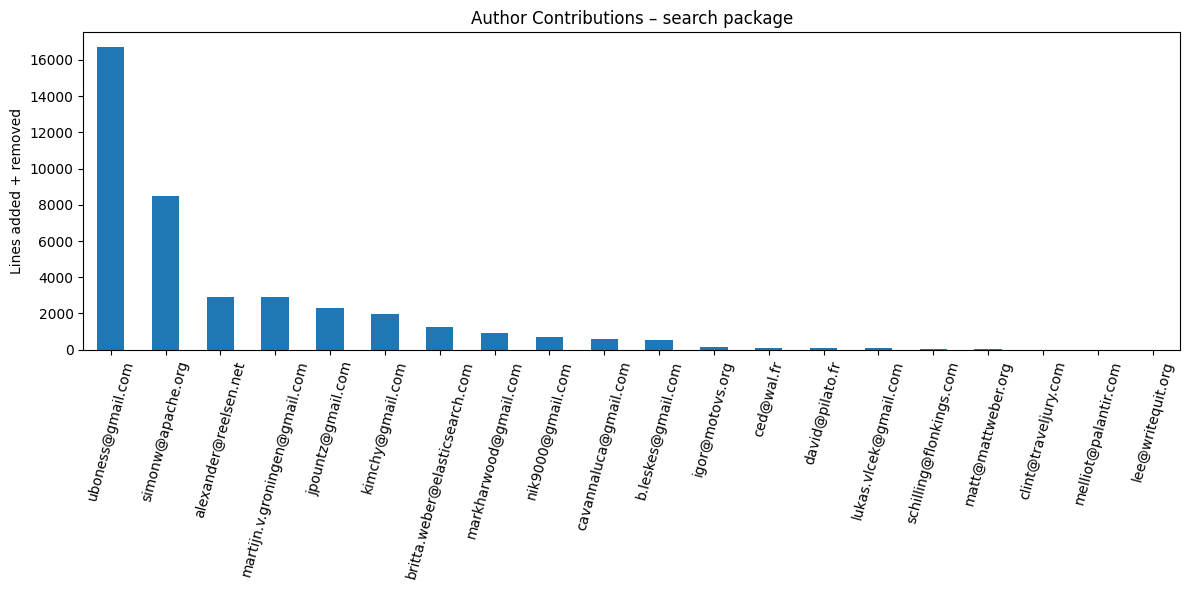

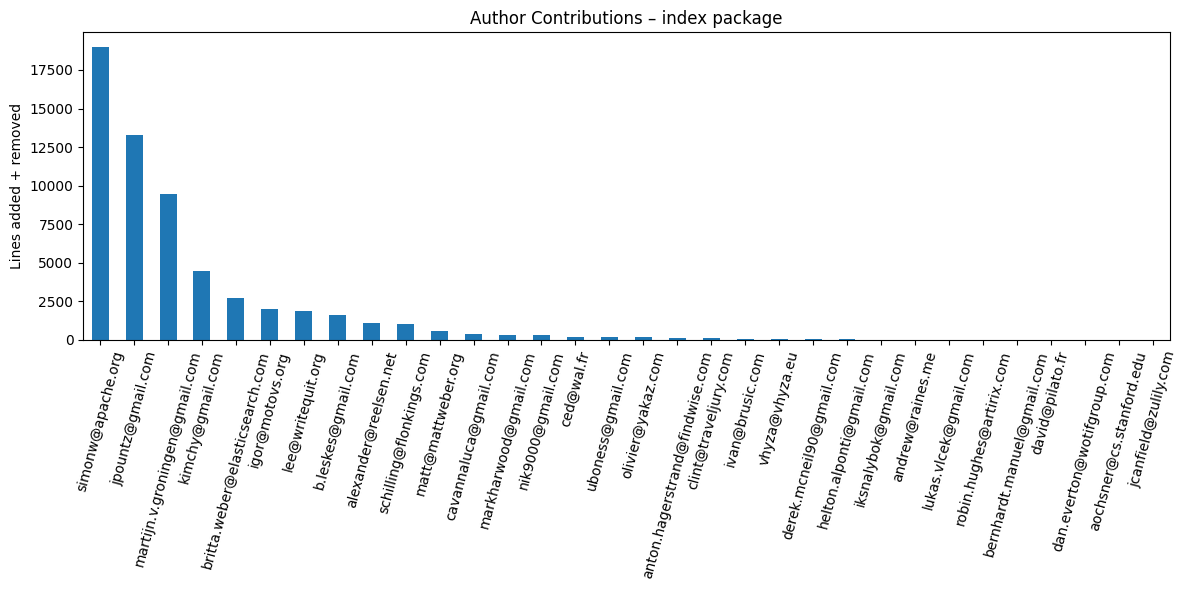

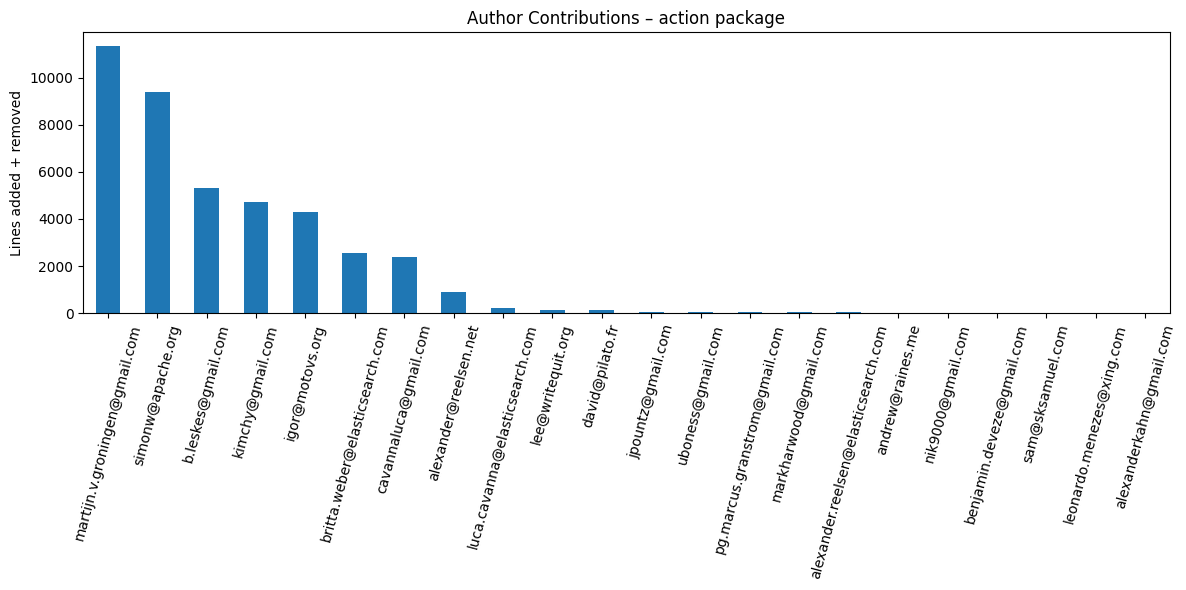

In [36]:
def author_contributions_by_package(package_path, modification_type: Modification):
    contributions = defaultdict(int)

    for commit in repo.traverse_commits():
        author = commit.author.email
        for m in commit.modified_files:
            if not m.filename.endswith(".java"):
                continue
            filepath = m.new_path or m.old_path
            if filepath is None or package_path not in filepath:
                continue
            added = m.added_lines
            removed = m.deleted_lines
            if modification_type == Modification.ADDED:
                contributions[author] += added
            elif modification_type == Modification.REMOVED:
                contributions[author] += removed
            elif modification_type == Modification.TOTAL:
                contributions[author] += added + removed
            elif modification_type == Modification.DIFF:
                contributions[author] += added - removed

    return dict(contributions)

packages = {
    "search": "src/main/java/org/elasticsearch/search",
    "index": "src/main/java/org/elasticsearch/index",
    "action": "src/main/java/org/elasticsearch/action"
}

results = {
    name: author_contributions_by_package(path, Modification.TOTAL)
    for name, path in packages.items()
}

def plot_contributions(contrib_dict, title):
    df = pandas.DataFrame.from_dict(contrib_dict, orient="index", columns=["lines"])
    df = df.sort_values("lines", ascending=False)

    matplotlib.pyplot.figure(figsize=(12, 6))
    df["lines"].plot(kind="bar")
    matplotlib.pyplot.ylabel("Lines added + removed")
    matplotlib.pyplot.title(title)
    matplotlib.pyplot.xticks(rotation=75)
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

plot_contributions(results["search"], "Author Contributions – search package")
plot_contributions(results["index"], "Author Contributions – index package")
plot_contributions(results["action"], "Author Contributions – action package")

### Search Package
The search package shows a strongly skewed contribution distribution. One main author dominates the changes, followed by a small group of secondary contributors, and a long tail of minor ones. This indicates centralized ownership of the search functionality, with most development driven by a core maintainer.

### Index Package
The index package follows a similar skewed pattern but involves roughly twice as many contributing authors. While a core group still performs most of the work, the broader contributor base suggests that indexing is a more cross-cutting concern, requiring changes from multiple developers across the system.

### Action Package
The action package exhibits a distribution comparable to the search package, with a similar number of contributing authors and a clear dominance of a few main contributors. This suggests stable ownership and limited need for widespread collaboration in this subsystem.

### Overall Interpretation
Across all three packages, contributions follow a core–periphery model. A small number of core developers account for most of the changes, while many authors contribute marginally. The index package stands out as the most collaboratively modified component, reflecting its central role in Elasticsearch’s architecture.

## Task 2: Knowledge loss

We now want to analyze the knowledge loss when the main contributor of the analyzed project would leave. For this we will use the circle packaging layout introduced in the "Code as a Crime Scene" book. This assignment includes the necessary `knowledge_loss.html` file as well as the `d3` folder for all dependencies. You task is to create the `output.json` file according to the specification below. This file can then be visualized with the files provided.

For showing the visualization, once you have the output as `output.json` you should
* make sure to have the `knowledge_loss.html` file in the same folder
* start a local HTTP server in the same folder (e.g. with python `python3 -m http.server`) to serve the html file (necessary for d3 to work)
* open the served `knowledge_loss.html` and look at the visualization

For the package you identify as the worst in terms of knowledge loss, investigate the author contributions using the function defined in the previous exercise and comment how the situation is, e.g. how big the gap between the main author and the second biggest contributor for the selected package is.

### Output Format for Visualization

* `root` is always the root of the tree
* `size` should be the total number of lines of contribution
* `weight` can be set to the same as `size`
* `ownership` should be set to the percentage of contributions from the main author (e.g. 0.98 for 98% if contributions coming from the main author)

```
{
  "name": "root",
  "children": [
    {
      "name": "test",
      "children": [
        {
          "name": "benchmarking",
          "children": [
            {
              "author_color": "red",
              "size": "4005",
              "name": "t6726-patmat-analysis.scala",
              "weight": 1.0,
              "ownership": 0.9,
              "children": []
            },
            {
              "author_color": "red",
              "size": "55",
              "name": "TreeSetIterator.scala",
              "weight": 0.88,
              "ownership": 0.9,
              "children": []
            }
          ]
        }
      ]
    }
  ]
}
```

### JSON Export

For exporting the data to JSON you can use the following snippet:

```
import json

with open("output.json", "w") as file:
    json.dump(tree, file, indent=4)
```

In [43]:
file_author_contrib = defaultdict(lambda: defaultdict(int))

for commit in repo.traverse_commits():
    author = commit.author.email
    for m in commit.modified_files:
        if not m.filename.endswith(".java"):
            continue
        filepath = m.new_path or m.old_path
        if filepath is None:
            continue
        contribution = m.added_lines + m.deleted_lines
        file_author_contrib[filepath][author] += contribution

def insert_file(tree, path_parts, file_data):
    if not path_parts:
        tree["children"].append(file_data)
        return
    current = path_parts[0]
    for child in tree["children"]:
        if child["name"] == current:
            insert_file(child, path_parts[1:], file_data)
            return
    new_node = {"name": current, "children": []}
    tree["children"].append(new_node)
    insert_file(new_node, path_parts[1:], file_data)

tree = {"name": "root", "children": []}

for filepath, authors in file_author_contrib.items():
    total = sum(authors.values())
    if total == 0:
        continue
    main_author_contrib = max(authors.values())
    ownership = round(main_author_contrib / total, 2)
    file_node = {
        "name": os.path.basename(filepath),
        "size": total,
        "weight": total,
        "ownership": ownership,
        "author_color": "red",
        "children": []
    }
    path_parts = filepath.split(os.sep)[:-1]
    insert_file(tree, path_parts, file_node)

with open("output.json", "w") as file:
    json.dump(tree, file, indent=4)

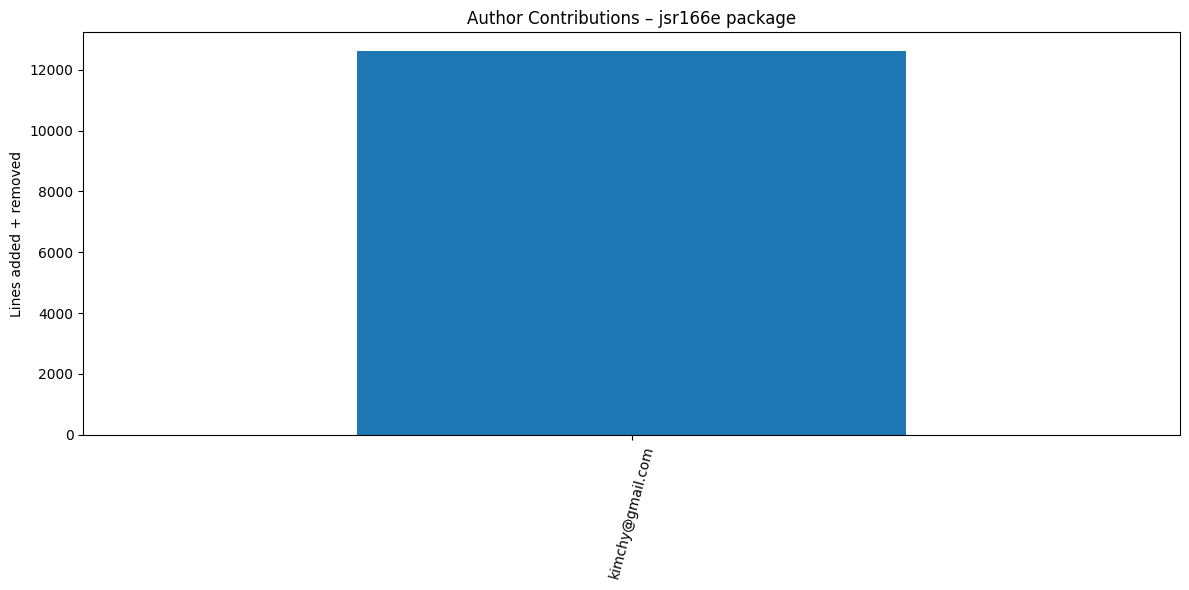

In [46]:
packages2 = {
    "jsr166e": "src/main/java/jsr166e",
}

results2 = {
    name: author_contributions_by_package(path, Modification.TOTAL)
    for name, path in packages2.items()
}

plot_contributions(results2["jsr166e"], "Author Contributions – jsr166e package")

## Task 3: Code Churn Analysis

The third and last task is to analyze the code churn of the _elasticsearch_ project. For this analysis we look at the code churn, meaning the daily change in the total number of lines of the project. Visualize the code churn over time bucketing the data by day. Remember that you'll need to interpolate the data for days when there are no commits. Chose an interpolation strategy and justify it.

Look at the churn trend over time and identify two outliers. For each of them:
- identify if it was caused by a single or multiple commits (since you are bucketing the data by day)
- find the hash of the involved commit(s)
- find the involved files
- look at the actual diff

Based on the above, discuss if the outlier is a false positive or should be a reason for concern.

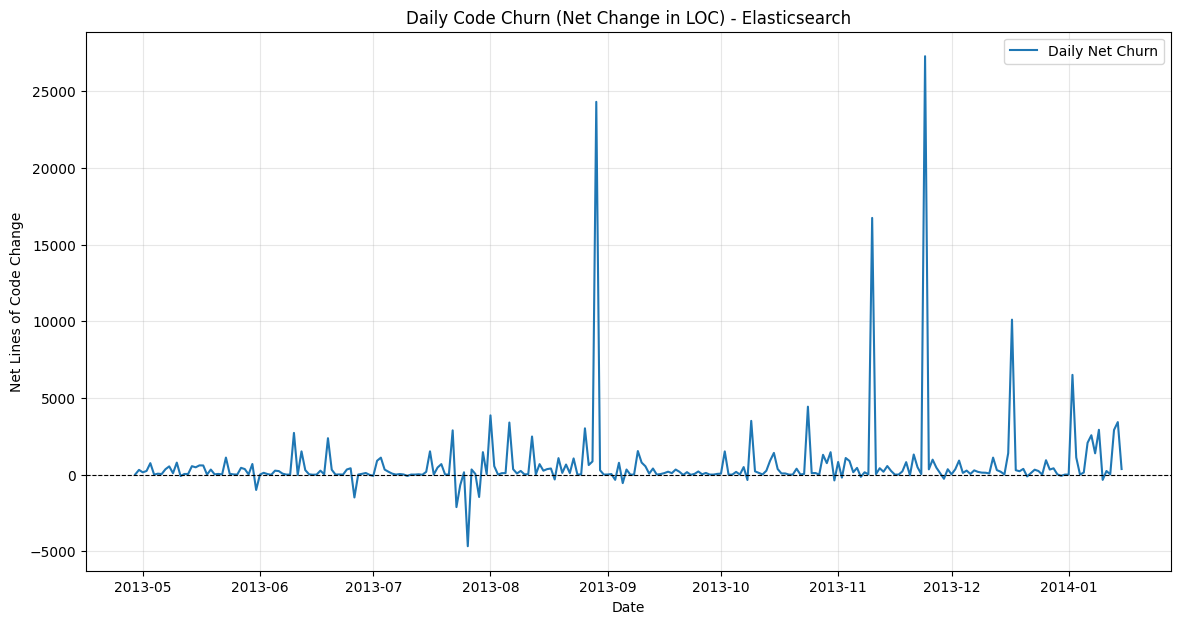

In [4]:
data = []

for commit in repo.traverse_commits():
    added = 0
    removed = 0
    for modification in commit.modified_files:
        added += modification.added_lines
        removed += modification.deleted_lines

    net_change = added - removed

    data.append({
        'date': pandas.to_datetime(commit.committer_date).date(),
        'hash': commit.hash,
        'message': commit.msg,
        'net_change': net_change,
        'added': added,         # Added back
        'removed': removed,     # Added back
        'files_count': len(commit.modified_files) # Added back
    })

dataframe_churn = pandas.DataFrame(data)
dataframe_churn['date'] = pandas.to_datetime(dataframe_churn['date'])

daily_churn = dataframe_churn.groupby('date')['net_change'].sum()

date_range = pandas.date_range(start=daily_churn.index.min(), end=daily_churn.index.max())
daily_churn_interpolated = daily_churn.reindex(date_range, fill_value=0)

matplotlib.pyplot.figure(figsize=(14, 7))
matplotlib.pyplot.plot(daily_churn_interpolated.index, daily_churn_interpolated.values, label='Daily Net Churn', color='tab:blue')
matplotlib.pyplot.axhline(0, color='black', linewidth=0.8, linestyle='--')
matplotlib.pyplot.title('Daily Code Churn (Net Change in LOC) - Elasticsearch')
matplotlib.pyplot.xlabel('Date')
matplotlib.pyplot.ylabel('Net Lines of Code Change')
matplotlib.pyplot.legend()
matplotlib.pyplot.grid(True, alpha=0.3)
matplotlib.pyplot.show()

Zero-filling was used as interpolation strategy, as no commits occurred on a specific day, the "change in the total number of lines" for that day is effectively 0.

### Outlier Analysis

In [17]:
max_added_date = daily_churn_interpolated.idxmax()
max_removed_date = daily_churn_interpolated.idxmin()

outlier_dates = [max_added_date, max_removed_date]

for date in outlier_dates:
    date_str = date.strftime('%Y-%m-%d')
    net_val = daily_churn_interpolated.loc[date]
    print(f"Date: {date_str} | Total Net Change: {net_val}")

    commits_on_day = dataframe_churn[dataframe_churn['date'] == date]
    print(f"Commits involved: {len(commits_on_day)}")

    for idx, row in commits_on_day.iterrows():
        print(f"  > Commit: {row['hash']}")
        # Only print the first line of the message to avoid clutter
        print(f"    Message: {row['message'].splitlines()[0]}") 
        print(f"    Files Modified: {row['files_count']}")
        print(f"    Lines Added: {row['added']} | Lines Removed: {row['removed']}")
        print("-" * 40)
    print("\n")

Date: 2013-11-24 | Total Net Change: 27282
Commits involved: 5
  > Commit: c7f6c5266d15fefa1a5ce9ae7ffc519c5ff8abbe
    Message: initial commit of the aggregations module
    Files Modified: 248
    Lines Added: 28385 | Lines Removed: 734
----------------------------------------
  > Commit: 8fda8aaabfa2e99e140093d8949fdf9fc72605be
    Message: force default codec
    Files Modified: 4
    Lines Added: 40 | Lines Removed: 8
----------------------------------------
  > Commit: 28adbd475dbaa9ef689cabcc501004f05b74a8b7
    Message: added a waitForGreen condition for the unmapped tests on missing agg
    Files Modified: 1
    Lines Added: 4 | Lines Removed: 0
----------------------------------------
  > Commit: 8e17d636ef441a9be80977d34acfaabc12982eb7
    Message: Upgrade to Lucene 4.6
    Files Modified: 38
    Lines Added: 118 | Lines Removed: 667
----------------------------------------
  > Commit: e3d4d73242d215389280b1d7b9facb7b1bd9bd7d
    Message: Local primaries should be preferred 

### Outlier Analysis Discussion

Based on the code churn analysis, two significant outliers were identified. Below is the discussion regarding their causes and implications.

#### 1. Positive Outlier: November 24, 2013
* **Observation:** This date shows a massive spike with a net addition of **+27,282 lines**.
* **Cause:** The primary driver was commit `c7f6c5266d15fefa1a5ce9ae7ffc519c5ff8abbe`.
* **Commit Message:** *"initial commit of the aggregations module"*
* **Details:** This commit added **28,385 lines** across **248 files**.
* **Discussion:** This outlier is a **False Positive** for concern. It does not indicate instability or "churn" in the negative sense (i.e., rewriting the same code repeatedly). Instead, it marks the introduction of a significant new architectural feature—the Aggregations module—which is a productive expansion of the codebase.

#### 2. Negative Outlier: July 26, 2013
* **Observation:** This date shows a significant drop with a net deletion of **-4,671 lines**.
* **Cause:** While multiple commits occurred, the drop was caused by commit `976152b23e2fe0b658b5b7c3ed225ff76b0a798b`.
* **Commit Message:** *"enable sys out check + remove unused code"*
* **Details:** This commit removed **5,748 lines** while only modifying **11 files**.
* **Discussion:** This outlier is a **False Positive** for knowledge loss. The commit message explicitly states the intent to "remove unused code." This represents a maintenance activity (removing dead code/technical debt) rather than the destruction of active project value or knowledge.

## Usage of AI

We used AI tools to support a few focused, non-substantive parts of this assignment. Specifically, AI assistance was used to:

- Improve the formatting and wording of markdown cells in this file for clarity and readability.  
- Prettify print statements 
- Assist with Matplotlib plotting code.

All analytical decisions, interpretations of results, and final write-ups were produced by the authors.
